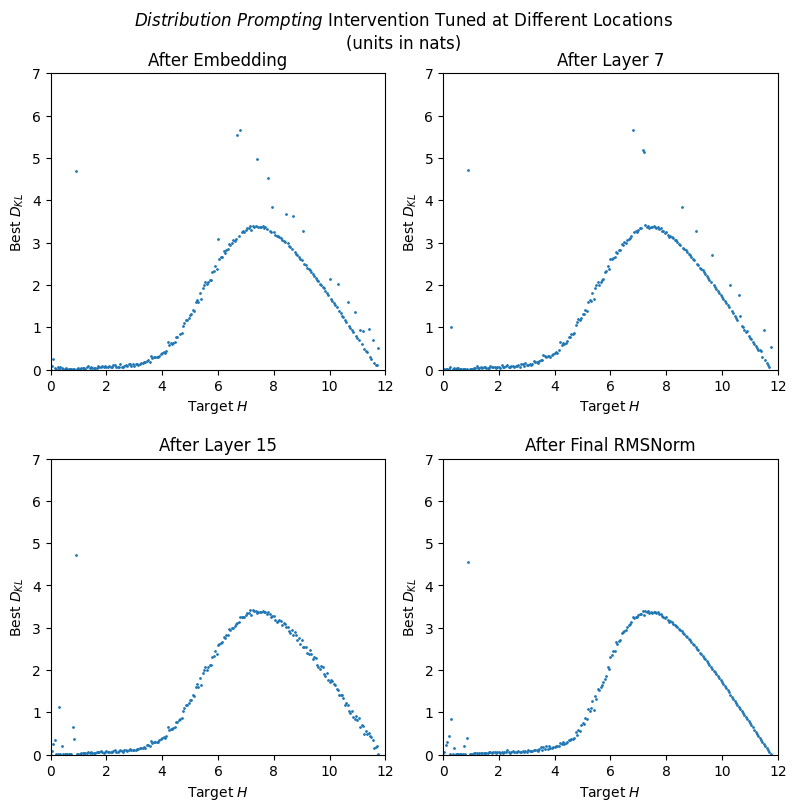

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

CSV_PATHS = {
    'embed.csv': 'After Embedding',
    'l7.csv': 'After Layer 7',
    'l15.csv': 'After Layer 15',
    'postnorm.csv': 'After Final RMSNorm'
}

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('$\\it{Distribution~Prompting}$ Intervention Tuned at Different Locations\n(units in nats)')
fig.tight_layout()
fig.subplots_adjust(top=0.9, hspace=0.3)
axs = axs.flatten()

for i, (path, title) in enumerate(list(CSV_PATHS.items())):
    df = pd.read_csv(path)
    axs[i].set(xlim=(0, 12), ylim=(0, 7), xlabel="Target $H$", ylabel="Best $D_{KL}$", title=title)
    axs[i].scatter(df['target_entropy'], df['best_loss'], s=1)

for j in range(i + 1, len(axs)): axs[j].set_axis_off() # hide remaining, if any

plt.show()

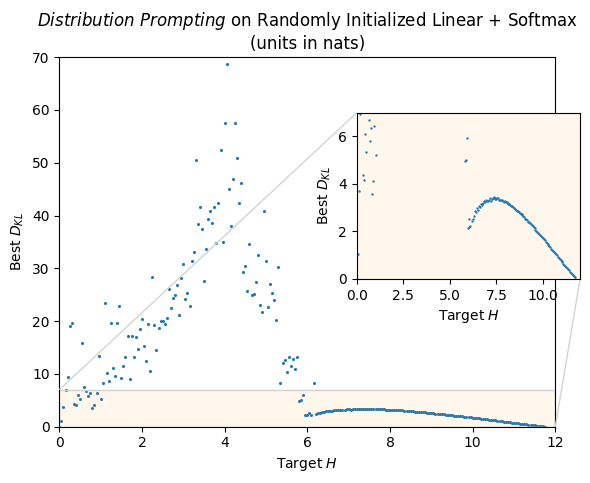

In [68]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

df = pd.read_csv('linsoftmax.csv')
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.scatter(df['target_entropy'], df['best_loss'], s=1.5)
ax.set(xlim=(0, 12), ylim=(0, 70), xlabel="Target $H$", ylabel="Best $D_{KL}$",
       title="$\\it{Distribution~Prompting}$ on Randomly Initialized Linear + Softmax\n(units in nats)")

ax.axhspan(0, 7, color="orange", alpha=0.08)

axins = ax.inset_axes([0.6, 0.4, 0.45, 0.45])
axins.axhspan(0, 7, color="orange", alpha=0.08)
axins.scatter(df['target_entropy'], df['best_loss'], s=0.5)
axins.set(xlim=(0, 12), ylim=(0, 7), xlabel="Target $H$", ylabel="Best $D_{KL}$")
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="lightgray")
plt.show()